# Data Loading

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "src").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("Could not locate the project root.")
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
    
from src.detector.data import (
    build_grouped_volume_registry,
    load_e2e_volume,
    select_bscan,
)

E2E_DIRECTORY = (
    PROJECT_ROOT
    / "data"
    / "heyex"
    / "meta"
)

registry = build_grouped_volume_registry(
    e2e_directory=E2E_DIRECTORY,
    progression_groups={
        "fast": [8, 9, 12, 41, 49],
        "slow": [17, 23, 35, 36, 47],
    },
)

record = registry[0]

volume = load_e2e_volume(
    record.e2e_path
)

bscan_index, bscan = select_bscan(
    volume,
    selection="center",
)

print("Subject:", record.subject_id)
print("Group:", record.progression_group)
print("Volume shape:", volume.shape)
print("Selected B-scan:", bscan_index)
print("B-scan shape:", bscan.shape)

Subject: 8
Group: fast
Volume shape: (97, 496, 512)
Selected B-scan: 48
B-scan shape: (496, 512)


# Preprocessing

In [2]:
from src.detector.preprocessing import (
    preprocess_bscan,
)

# --------------------------------------------------
# Preprocessing configuration
# --------------------------------------------------

PREPROCESSING_CONFIG = {
    "layer_name": "BM",

    # Flattening
    "reference_row": None,
    "flatten_fill_value": 0.0,

    # Crop
    "depth_below_layer": 150,
    "include_boundary": True,
    "require_full_depth": False,
    "crop_fill_value": 0.0,

    # Normalization
    "normalization_method": "zscore",
    "lower_percentile": 1.0,
    "upper_percentile": 99.0,

    # Denoising
    "denoise_method": "gaussian",
    "gaussian_sigma": (1.0, 0.5),
}

# --------------------------------------------------
# Run preprocessing
# --------------------------------------------------

result = preprocess_bscan(
    volume=volume,
    bscan_index=bscan_index,
    **PREPROCESSING_CONFIG,
)

print("Completed preprocessing.")
print(result)

Completed preprocessing.
PreprocessedScan(bscan_index=48, layer_name='BM', raw_bscan=array([[0., 0., 0., ..., 0., 0., 0.],
       [3., 0., 0., ..., 0., 1., 0.],
       [4., 0., 0., ..., 4., 2., 0.],
       ...,
       [0., 1., 6., ..., 0., 0., 0.],
       [0., 1., 5., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(496, 512), dtype=float32), layer_boundary=array([222.61269, 222.87262, 223.13268, 223.393  , 223.65387, 223.91563,
       224.17873, 224.44365, 224.71101, 224.98146, 225.25568, 225.53435,
       225.81812, 226.10757, 226.40327, 226.70561, 227.01497, 227.33163,
       227.65582, 227.9876 , 228.32697, 228.67381, 229.02792, 229.389  ,
       229.75667, 230.13048, 230.5099 , 230.89444, 231.2835 , 231.67651,
       232.0729 , 232.4721 , 232.87354, 233.2767 , 233.68106, 234.08612,
       234.49135, 234.89624, 235.30025, 235.7028 , 236.10336, 236.50136,
       236.89624, 237.28749, 237.67462, 238.05722, 238.43488, 238.80728,
       239.17422, 239.53555, 239.89125, 2

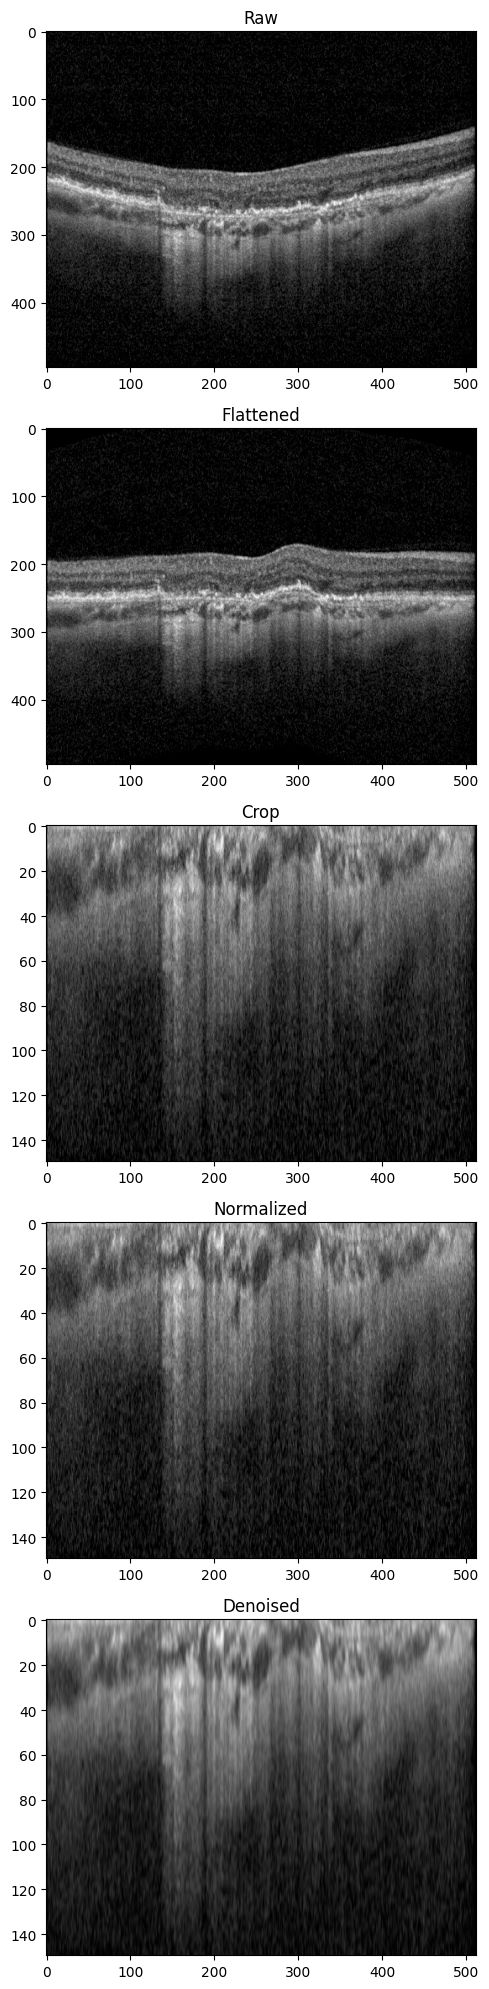

In [3]:
fig, axes = plt.subplots(
    5,
    1,
    figsize=(5,20),
)

axes[0].imshow(
    result.raw_bscan,
    cmap="gray",
    aspect="auto",
)
axes[0].set_title("Raw")

axes[1].imshow(
    result.flattened_bscan,
    cmap="gray",
    aspect="auto",
)
axes[1].set_title("Flattened")

axes[2].imshow(
    result.sub_layer_crop,
    cmap="gray",
    aspect="auto",
)
axes[2].set_title("Crop")

axes[3].imshow(
    result.normalized_scan,
    cmap="gray",
    aspect="auto",
)
axes[3].set_title("Normalized")

axes[4].imshow(
    result.denoised_scan,
    cmap="gray",
    aspect="auto",
)
axes[4].set_title("Denoised")

plt.tight_layout()

In [4]:
from pprint import pprint

pprint(result.metadata)

{'available_layers': ['ILM',
                      'BM',
                      'RNFL',
                      'GCL',
                      'IPL',
                      'INL',
                      'OPL',
                      'ELM',
                      'PR1',
                      'PR2',
                      'RPE'],
 'boundary_maximum': 283.439453125,
 'boundary_median': 255.50411987304688,
 'boundary_minimum': 211.09371948242188,
 'bscan_meta': {'acquisitionTime': '2024-02-16T23:22:37.164000',
                'aktImage': 48,
                'center_x': 0.249420166015625,
                'center_y': -0.15868902206420898,
                'end_pos': (10.255987167358398, 0.16282153129577637),
                'end_x': 10.255987167358398,
                'end_y': 0.16282153129577637,
                'imgSizeWidth': 511,
                'n_bscans': 97,
                'numAve': 0,
                'pos_unit': '°',
                'quality': 0.8416000008583069,
                'scale_y': 0.0

# Feature Extraction

In [5]:
FEATURE_CONFIG = {
    "window_width": 21, #TODO Tune
    "stride": 1, #TODO Tune
    "padding_mode": "reflect",

    "verticality_gradient_sigma": 1.0,
    "verticality_tensor_sigma": 2.0,
    "verticality_summary": "mean",

    "persistence_bright_percentile": 75.0, #TODO Tune
    "persistence_minimum_verticality": 0.20, #TODO Tune
    "persistence_method": "longest_run",
    "persistence_summary": "mean",

    "periodicity_minimum_lag": 2, #TODO Tune
    "periodicity_maximum_lag": 10, #TODO Tune
    "periodicity_use_absolute_correlation": False,

    "amplitude_statistic": "mean",
    "amplitude_percentile": 90.0,

    "heterogeneity_method": "column_std",

    "standardization_clip_limits": (-5.0, 5.0),
}

In [6]:
from src.detector.features import (
    extract_feature_signals,
)

feature_result = extract_feature_signals(
    image=result.denoised_scan,
    **FEATURE_CONFIG,
)

print("Feature extraction completed.")
print("Image shape:", result.denoised_scan.shape)
print("Number of evaluated positions:", feature_result.x_positions.size)
print(
    "Horizontal range:",
    feature_result.x_positions.min(),
    "to",
    feature_result.x_positions.max(),
)

print("\nRaw feature shapes:")
for feature_name, values in feature_result.raw_features.items():
    print(
        f"  {feature_name}: "
        f"shape={values.shape}, "
        f"min={values.min():.4f}, "
        f"max={values.max():.4f}, "
        f"mean={values.mean():.4f}"
    )

print("\nStandardized feature shapes:")
for feature_name, values in (
    feature_result.standardized_features.items()
):
    print(
        f"  {feature_name}: "
        f"shape={values.shape}, "
        f"min={values.min():.4f}, "
        f"max={values.max():.4f}, "
        f"mean={values.mean():.4f}"
    )

print(
    "\nVerticality map shape:",
    feature_result.verticality_map.shape,
)

print(
    "Persistence signal shape:",
    feature_result.persistence_signal.shape,
)

Feature extraction completed.
Image shape: (150, 512)
Number of evaluated positions: 512
Horizontal range: 0.0 to 511.0

Raw feature shapes:
  verticality: shape=(512,), min=0.1834, max=0.6135, mean=0.3434
  persistence: shape=(512,), min=0.0013, max=0.2324, mean=0.0944
  periodicity: shape=(512,), min=-0.0129, max=0.9629, mean=0.5632
  amplitude: shape=(512,), min=-0.6458, max=0.6933, mean=0.0016
  heterogeneity: shape=(512,), min=0.0206, max=0.3920, mean=0.1223

Standardized feature shapes:
  verticality: shape=(512,), min=-1.1790, max=2.2788, mean=0.1068
  persistence: shape=(512,), min=-1.0467, max=1.7860, mean=0.0942
  periodicity: shape=(512,), min=-2.3550, max=1.3816, mean=-0.1489
  amplitude: shape=(512,), min=-2.5357, max=3.4173, mean=0.3422
  heterogeneity: shape=(512,), min=-0.9049, max=3.5994, mean=0.3290

Verticality map shape: (150, 512)
Persistence signal shape: (512,)


In [7]:
feature_dataframe = feature_result.to_dataframe(
    include_standardized=True,
)

print("Feature DataFrame shape:", feature_dataframe.shape)

display(
    feature_dataframe.head(10)
)

Feature DataFrame shape: (512, 11)


,x_position,verticality,persistence,periodicity,amplitude,heterogeneity,verticality_standardized,persistence_standardized,periodicity_standardized,amplitude_standardized,heterogeneity_standardized
0,0.0,0.561045,0.062222,0.116090,-0.223064,0.285542,1.857021,-0.299611,-1.860938,-0.656374,2.308387
1,1.0,0.560261,0.062222,0.118035,-0.222275,0.285837,1.850716,-0.299611,-1.853490,-0.652867,2.311971
2,2.0,0.558064,0.061905,0.115762,-0.223383,0.285469,1.833058,-0.303502,-1.862195,-0.657790,2.307505
3,3.0,0.554225,0.060952,0.116829,-0.221761,0.286075,1.802192,-0.315175,-1.858109,-0.650579,2.314855
4,4.0,0.546968,0.058095,0.116320,-0.221066,0.286366,1.743844,-0.350195,-1.860060,-0.647493,2.318378
5,5.0,0.533745,0.054603,0.108757,-0.225298,0.284846,1.637530,-0.392996,-1.889017,-0.666305,2.299946
6,6.0,0.513008,0.049841,0.104005,-0.227391,0.284213,1.470812,-0.451362,-1.907213,-0.675610,2.292273
7,7.0,0.486235,0.043810,0.103111,-0.226058,0.284912,1.255557,-0.525292,-1.910637,-0.669683,2.300754
8,8.0,0.455430,0.038730,0.178849,-0.225574,0.285176,1.007890,-0.587549,-1.620628,-0.667534,2.303955
9,9.0,0.422252,0.033651,0.372404,-0.221139,0.287204,0.741151,-0.649805,-0.879489,-0.647814,2.328545


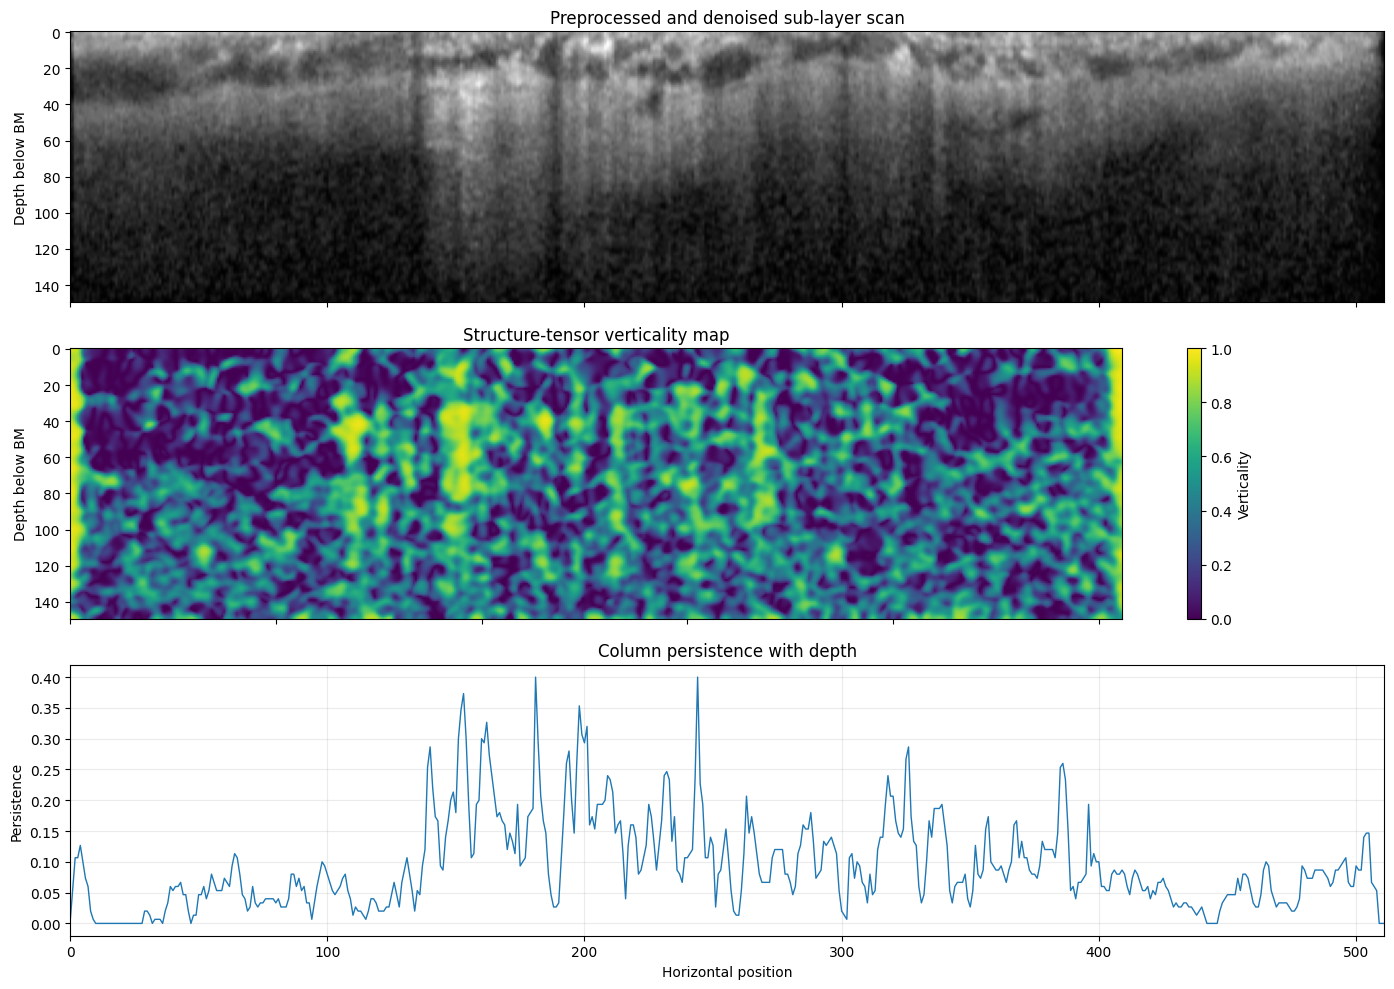

In [8]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 10),
    sharex=True,
)

axes[0].imshow(
    result.denoised_scan,
    cmap="gray",
    aspect="auto",
)

axes[0].set_title(
    "Preprocessed and denoised sub-layer scan"
)
axes[0].set_ylabel(
    "Depth below BM"
)

verticality_image = axes[1].imshow(
    feature_result.verticality_map,
    cmap="viridis",
    aspect="auto",
    vmin=0.0,
    vmax=1.0,
)

axes[1].set_title(
    "Structure-tensor verticality map"
)
axes[1].set_ylabel(
    "Depth below BM"
)

fig.colorbar(
    verticality_image,
    ax=axes[1],
    label="Verticality",
)

axes[2].plot(
    np.arange(
        feature_result.persistence_signal.size
    ),
    feature_result.persistence_signal,
    linewidth=1.0,
)

axes[2].set_xlim(
    0,
    result.denoised_scan.shape[1] - 1,
)
axes[2].set_title(
    "Column persistence with depth"
)
axes[2].set_xlabel(
    "Horizontal position"
)
axes[2].set_ylabel(
    "Persistence"
)
axes[2].grid(
    alpha=0.25,
)

plt.tight_layout()
plt.show()

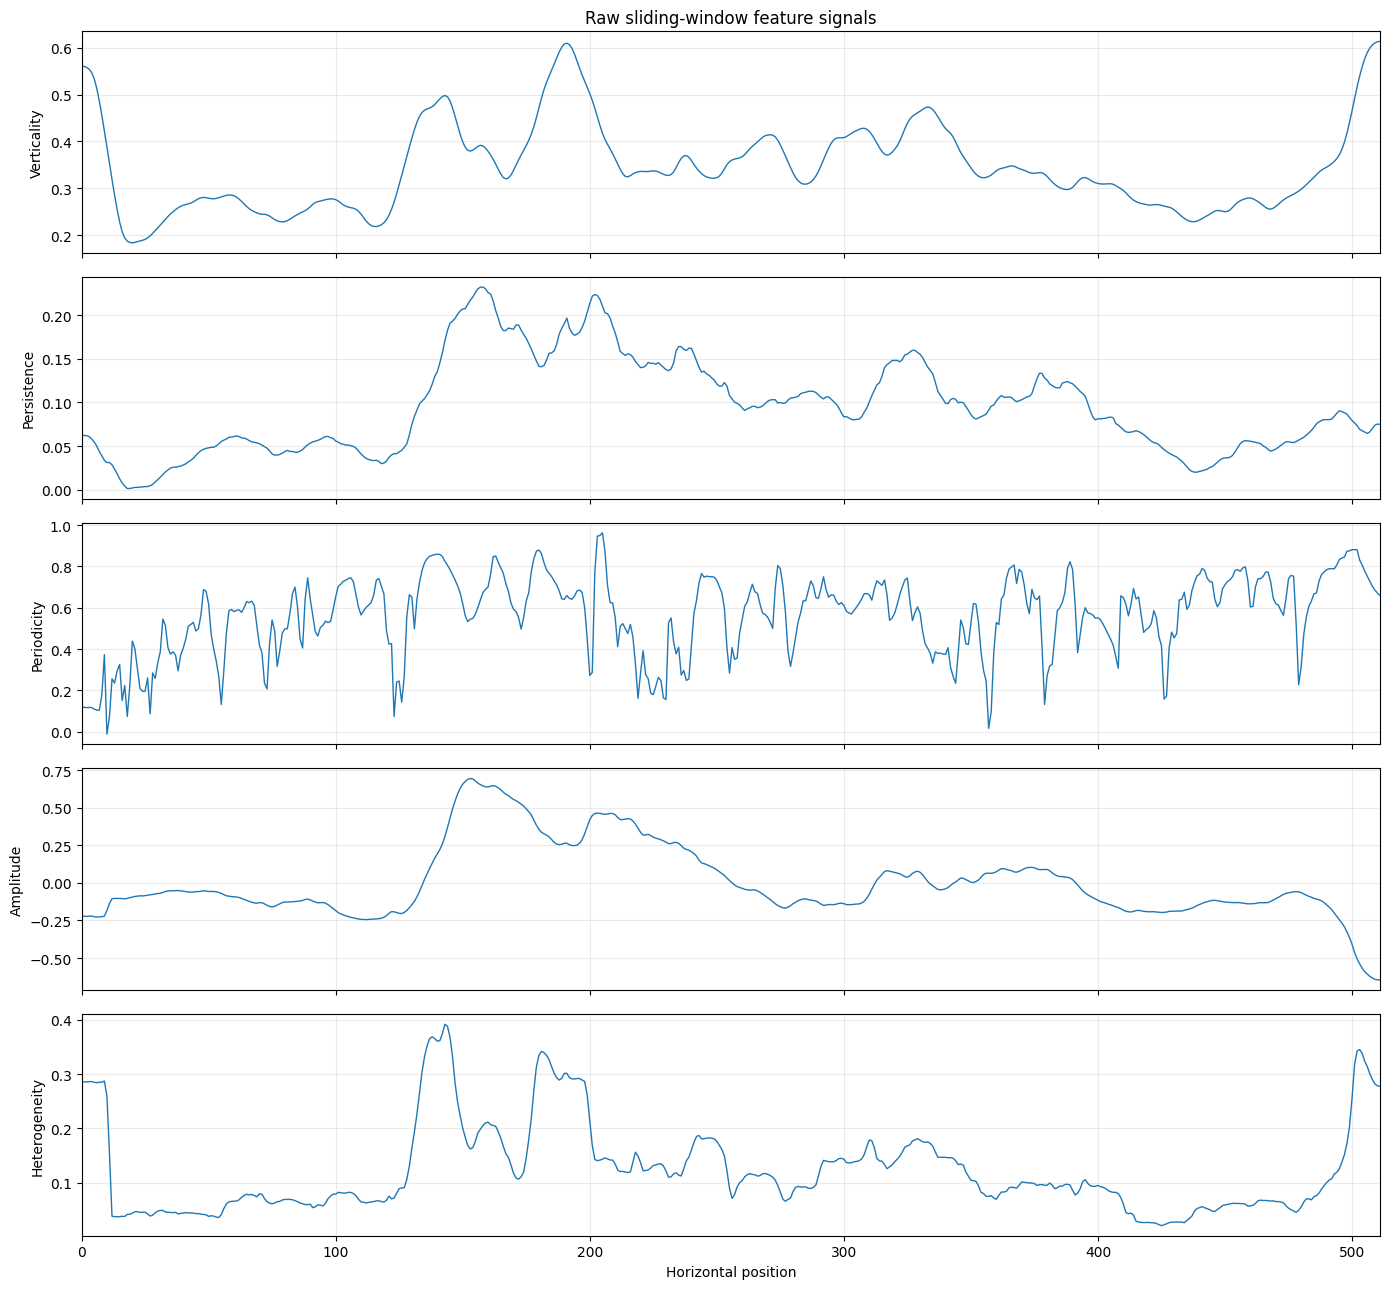

In [9]:
fig, axes = plt.subplots(
    5,
    1,
    figsize=(14, 13),
    sharex=True,
)

for axis, feature_name in zip(
    axes,
    (
        "verticality",
        "persistence",
        "periodicity",
        "amplitude",
        "heterogeneity",
    ),
):
    axis.plot(
        feature_result.x_positions,
        feature_result.raw_features[
            feature_name
        ],
        linewidth=1.0,
    )

    axis.set_ylabel(
        feature_name.title()
    )

    axis.grid(
        alpha=0.25,
    )

axes[0].set_title(
    "Raw sliding-window feature signals"
)

axes[-1].set_xlabel(
    "Horizontal position"
)

axes[-1].set_xlim(
    0,
    result.denoised_scan.shape[1] - 1,
)

plt.tight_layout()
plt.show()

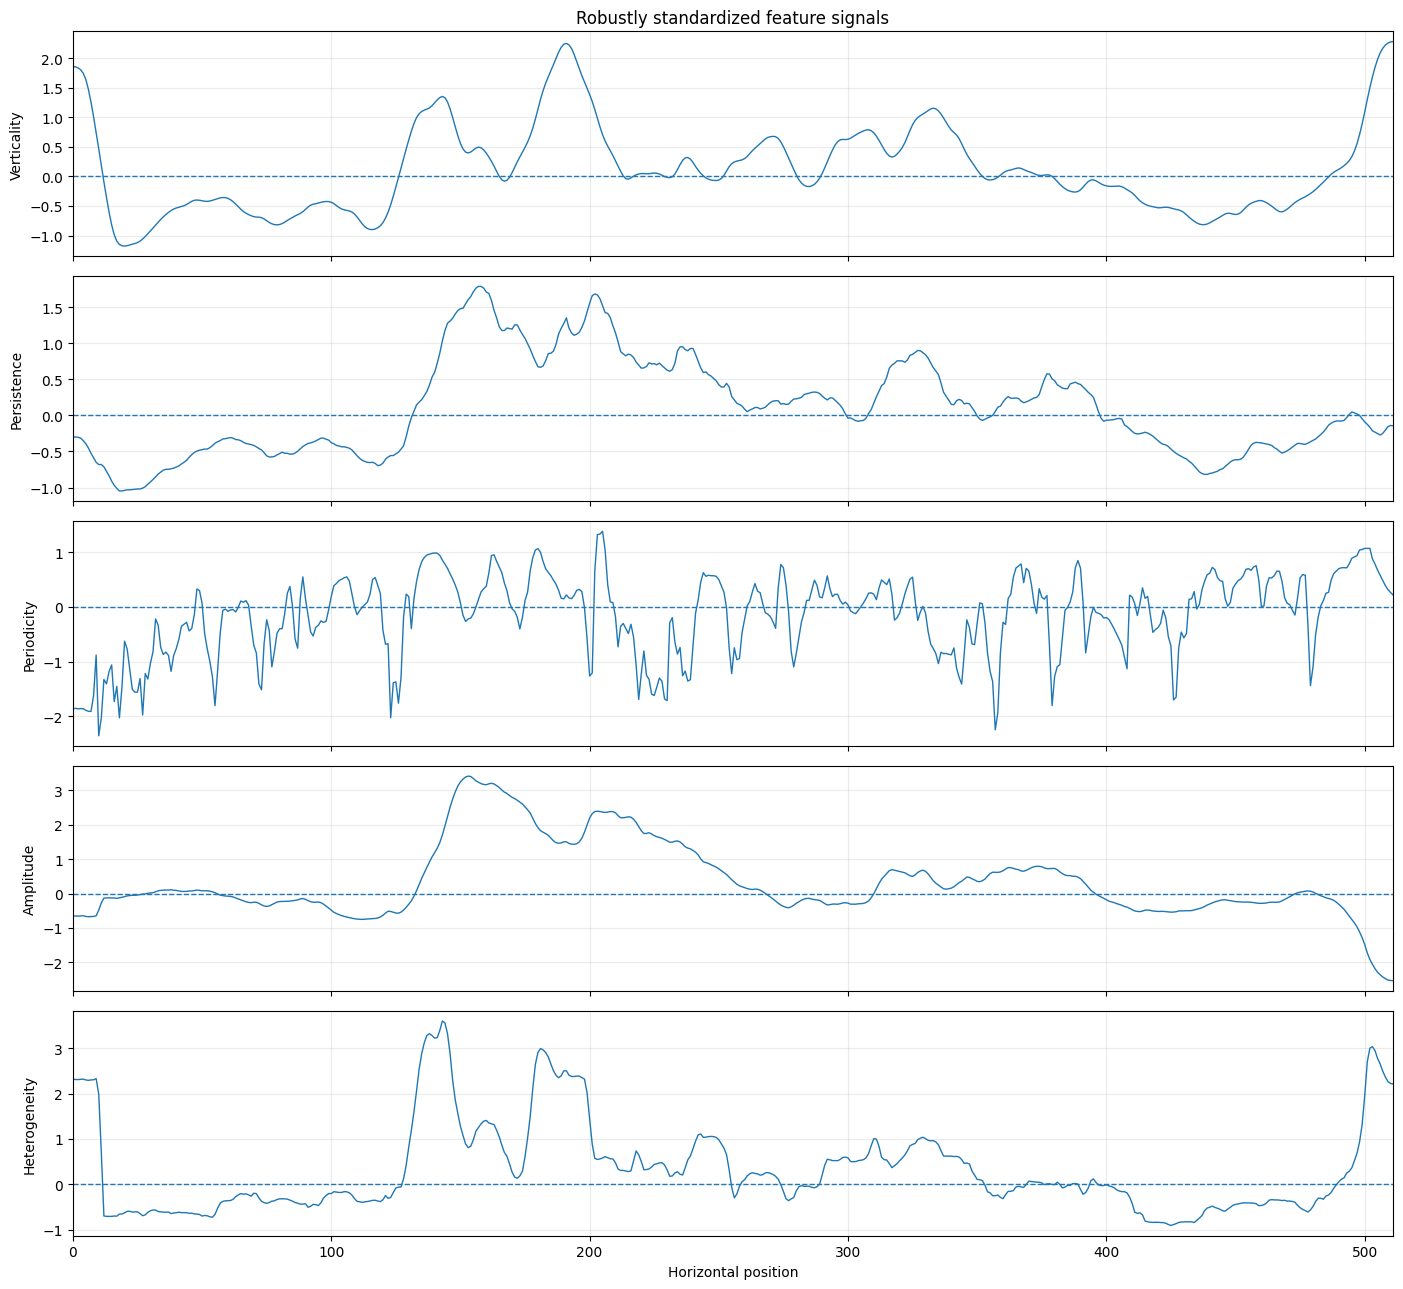

In [10]:
fig, axes = plt.subplots(
    5,
    1,
    figsize=(14, 13),
    sharex=True,
)

for axis, feature_name in zip(
    axes,
    (
        "verticality",
        "persistence",
        "periodicity",
        "amplitude",
        "heterogeneity",
    ),
):
    axis.plot(
        feature_result.x_positions,
        feature_result.standardized_features[
            feature_name
        ],
        linewidth=1.0,
    )

    axis.axhline(
        0.0,
        linestyle="--",
        linewidth=1.0,
    )

    axis.set_ylabel(
        feature_name.title()
    )

    axis.grid(
        alpha=0.25,
    )

axes[0].set_title(
    "Robustly standardized feature signals"
)

axes[-1].set_xlabel(
    "Horizontal position"
)

axes[-1].set_xlim(
    0,
    result.denoised_scan.shape[1] - 1,
)

plt.tight_layout()
plt.show()

In [11]:
# Install once if necessary:
# %pip install ipympl

%matplotlib widget

In [ ]:
from src.detector.visualization import (
    create_feature_overlay_viewer,
)

feature_overlay_viewer = create_feature_overlay_viewer(
    image=result.denoised_scan,
    feature_result=feature_result,

    # Show standardized features because these are the values that
    # will later enter the weighted detector score.
    use_standardized=True,

    # Begin with only one feature visible to avoid overlapping colors.
    initially_visible=(
        "heterogeneity",
    ),

    maximum_alpha=0.50,
    display_percentiles=(
        2.0,
        98.0,
    ),
)

feature_overlay_viewer.show()